In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from opacus import PrivacyEngine
import gc
import numpy as np


transform = transforms.Compose([
    transforms.ToTensor(),  
])

mnist_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
mnist_loader = DataLoader(dataset=mnist_dataset, batch_size=64, shuffle=True)

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), 
    transforms.Resize((28, 28)),               
    transforms.ToTensor(),                       
])


qmnist_dataset  = datasets.QMNIST(root='./data', train=True, transform=transform, download=True)
qmnist_loader  = DataLoader(dataset=qmnist_dataset, batch_size=1000, shuffle=False)

max_mnist_contribution = len(mnist_dataset) 
max_qmnist_contribution = len(qmnist_dataset) 
total_if_mnist_maxed = int(len(mnist_dataset) / 0.04)
total_if_qmnist_maxed = int(len(qmnist_dataset) / 0.96)
total_desired_size = min(total_if_mnist_maxed, total_if_qmnist_maxed)
mnist_size = int(0.04 * total_desired_size)
qmnist_size = int(0.96 * total_desired_size)
np.random.seed(42)
mnist_indices = np.random.choice(len(mnist_dataset), size=mnist_size, replace=False)
qmnist_indices = np.random.choice(len(qmnist_dataset), size=qmnist_size, replace=False)
mnist_subset = Subset(mnist_dataset, mnist_indices)
qmnist_subset = Subset(qmnist_dataset, qmnist_indices)
train_loader_public = DataLoader(dataset=mnist_subset, batch_size=64, shuffle=True)
train_loader_private = DataLoader(dataset=qmnist_subset, batch_size=64, shuffle=True)


test_dataset  = datasets.QMNIST(root='./data', train=False, transform=transform, download=True)
test_loader  = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)

In [2]:
print(f"\nDataset Information:")
print(f"Original MNIST training set: {len(mnist_dataset)} samples")
print(f"Original QMNIST training set: {len(qmnist_dataset)} samples")
print(f"Modified MNIST loader: {len(mnist_subset)} samples ({len(mnist_subset)/(len(mnist_subset)+len(qmnist_subset))*100:.1f}%)")
print(f"Modified QMNIST loader: {len(qmnist_subset)} samples ({len(qmnist_subset)/(len(mnist_subset)+len(qmnist_subset))*100:.1f}%)")
print(f"Test set: {len(test_dataset)} samples")


Dataset Information:
Original MNIST training set: 60000 samples
Original QMNIST training set: 60000 samples
Modified MNIST loader: 2500 samples (4.0%)
Modified QMNIST loader: 60000 samples (96.0%)
Test set: 60000 samples


In [3]:
print(f"\nData Loader Batch Information:")
for batch_idx, (data, target) in enumerate(train_loader_public):
    print(f"MNIST batch {batch_idx + 1}: {data.shape}, labels: {target.shape}")
    if batch_idx == 0:  
        break

for batch_idx, (data, target) in enumerate(train_loader_private):
    print(f"QMNIST batch {batch_idx + 1}: {data.shape}, labels: {target.shape}")
    if batch_idx == 0:
        break


Data Loader Batch Information:
MNIST batch 1: torch.Size([64, 1, 28, 28]), labels: torch.Size([64])
QMNIST batch 1: torch.Size([64, 1, 28, 28]), labels: torch.Size([64])


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class mnist(nn.Module):
    def __init__(self):
        super(mnist, self).__init__()
        self.conv1 = nn.Conv2d(1,6, kernel_size=5, stride=1, padding=2)
        self.tanh1 = nn.Tanh()
        self.pool1 = nn.AvgPool2d(kernel_size=2,  stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1)
        self.tanh2 = nn.Tanh()
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5, stride=1)
        self.tanh3 = nn.Tanh()
        self.fc1 = nn.Linear(120, 84)
        self.tanh4 = nn.Tanh()
        self.fc2 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool1(self.tanh1(self.conv1(x)))
        x = self.pool2(self.tanh2(self.conv2(x)))
        x = self.tanh3(self.conv3(x))
        x = x.view(-1, 120)  # Flatten the tensor
        x = self.tanh4(self.fc1(x))
        x = self.fc2(x)
        return x

model = mnist()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

privacy_engine = PrivacyEngine()


gc.collect()

/opt/anaconda3/lib/python3.12/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(


20

In [5]:
epochs_1 = 5
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []
for epoch in range(epochs_1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader_public:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(f'Epoch [{epoch + 1}/10]')
    print("Training loss", (running_loss / total))  
    train_losses.append(running_loss / total)
    print("Training accuracy", (correct *100/ total),'%')
    train_accuracies.append(correct * 100 / total)
    gc.collect()


    model.eval()
    running_loss_eval = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss_eval += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print("Testing loss", (running_loss / total))
    test_losses.append(running_loss_eval / total)
    print("Testing accuracy", (correct*100 / total),'%')
    test_accuracies.append(correct * 100 / total)
    gc.collect()

Epoch [1/10]
Training loss 2.2778482036590577
Training accuracy 23.28 %
Testing loss 0.0949103418191274
Testing accuracy 43.75333333333333 %
Epoch [2/10]
Training loss 2.0324923805236814
Training accuracy 47.52 %
Testing loss 0.08468718252182007
Testing accuracy 48.49 %
Epoch [3/10]
Training loss 1.2585155197143554
Training accuracy 62.88 %
Testing loss 0.05243814665476481
Testing accuracy 76.69 %
Epoch [4/10]
Training loss 0.7140518699169159
Training accuracy 79.72 %
Testing loss 0.02975216124653816
Testing accuracy 82.37833333333333 %
Epoch [5/10]
Training loss 0.5337462593793869
Training accuracy 84.2 %
Testing loss 0.02223942747414112
Testing accuracy 84.94833333333334 %


In [6]:
epochs_2 = 10
train_losses_2 = []
train_accuracies_2 = []
test_losses_2 = []
test_accuracies_2 = []
model.train()
target_delta = 1e-5
model, optimizer, train_loader_private = privacy_engine.make_private_with_epsilon(
    module=model,
    optimizer=optimizer,
    data_loader=train_loader_private,
    epochs=10,
    target_epsilon=3,
    target_delta=target_delta,
    max_grad_norm=0.1,
)
for epoch in range(epochs_2):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader_private:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(f'Epoch [{epoch + 1}/10]')
    print("Training loss", (running_loss / total))
    train_losses_2.append(running_loss / total)
    print("Training accuracy", (correct *100/ total),'%')
    train_accuracies_2.append(correct * 100 / total)
    gc.collect()

    epsilon = privacy_engine.get_epsilon(delta=target_delta)
    print(f"Privacy Budget (epsilon, delta): ({epsilon:.2f}, {target_delta})")

    model.eval()
    running_loss_eval = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss_eval += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print("Testing loss", (running_loss / total))
    test_losses_2.append(running_loss_eval / total)
    print("Testing accuracy", (correct*100 / total),'%')
    test_accuracies_2.append(correct * 100 / total)

    gc.collect()
    model.eval()
    correct = 0
    total = 0
    eval_loss = 0.0

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            eval_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

print(f"Test Loss: {eval_loss / total:.4f}, Accuracy: {100 * correct / total:.2f}%")

/opt/anaconda3/lib/python3.12/site-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


Epoch [1/10]
Training loss 0.5371705483624475
Training accuracy 81.49382016857115 %
Privacy Budget (epsilon, delta): (1.79, 1e-05)
Testing loss 0.5374749450065196
Testing accuracy 81.47166666666666 %
Epoch [2/10]
Training loss 0.5353938090589109
Training accuracy 82.00731747879594 %
Privacy Budget (epsilon, delta): (2.07, 1e-05)
Testing loss 0.5365538289785385
Testing accuracy 82.72166666666666 %
Epoch [3/10]
Training loss 0.5150082159996435
Training accuracy 83.87458006718926 %
Privacy Budget (epsilon, delta): (2.26, 1e-05)
Testing loss 0.5135576095245779
Testing accuracy 84.94333333333333 %
Epoch [4/10]
Training loss 0.4799812946927942
Training accuracy 85.87021830562787 %
Privacy Budget (epsilon, delta): (2.40, 1e-05)
Testing loss 0.4793093208802243
Testing accuracy 86.52166666666666 %
Epoch [5/10]
Training loss 0.4699233112453349
Training accuracy 87.0633893919793 %
Privacy Budget (epsilon, delta): (2.52, 1e-05)
Testing loss 0.472225935470437
Testing accuracy 87.49 %
Epoch [6/10]
T

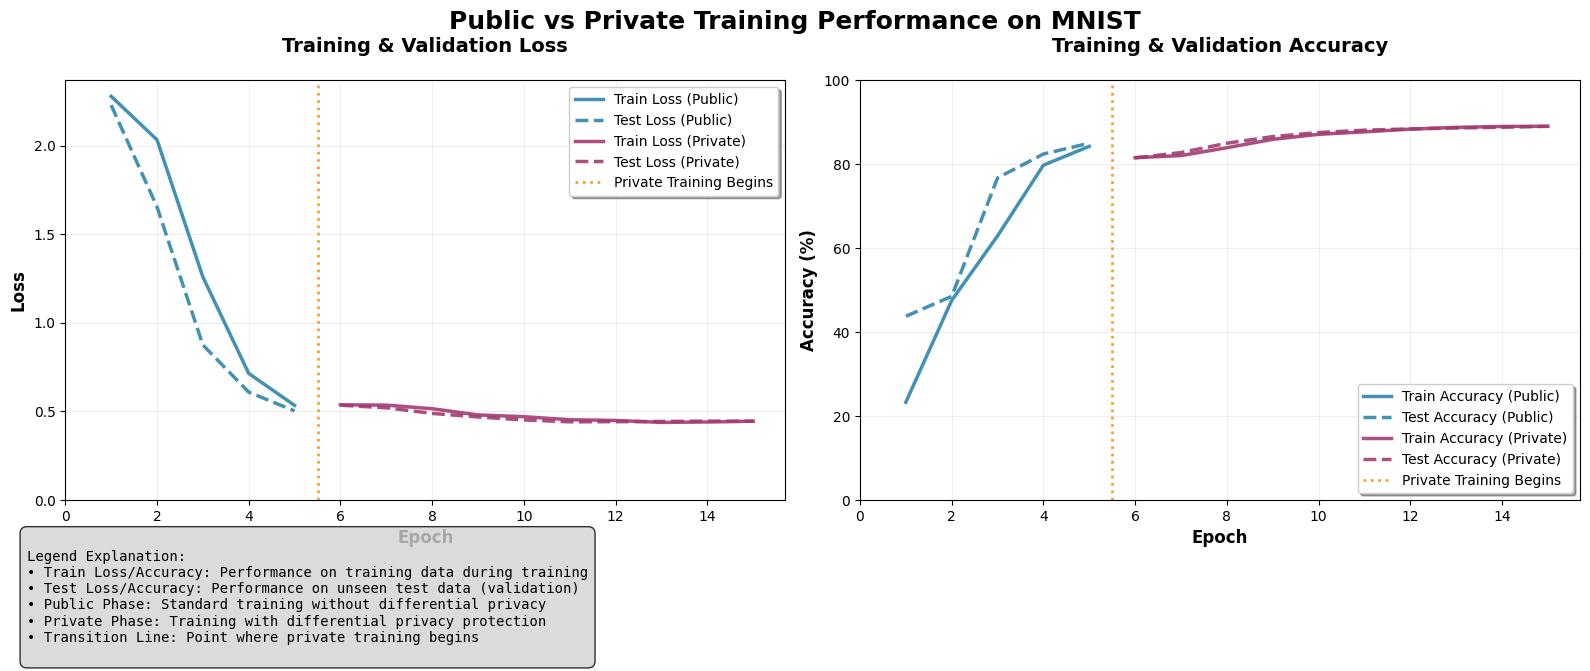

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Combine loss and accuracy for plotting
full_train_losses = train_losses + train_losses_2
full_test_losses = test_losses + test_losses_2
full_train_accuracies = train_accuracies + train_accuracies_2
full_test_accuracies = test_accuracies + test_accuracies_2

# Create epoch ranges
public_epochs = list(range(1, epochs_1 + 1))
private_epochs = list(range(epochs_1 + 1, epochs_1 + epochs_2 + 1))

# Set up the figure with improved styling
plt.rcParams.update({'font.size': 10})  # Set default font size
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Define colors for consistency
public_color = '#2E86AB'    # Blue
private_color = '#A23B72'   # Red/Purple
transition_color = '#F18F01' # Orange

# --- Loss Plot ---
ax1.plot(public_epochs, train_losses, color=public_color, linewidth=2.5, 
         label='Train Loss (Public)', alpha=0.9)
ax1.plot(public_epochs, test_losses, color=public_color, linewidth=2.5, 
         linestyle='--', label='Test Loss (Public)', alpha=0.9)

ax1.plot(private_epochs, train_losses_2, color=private_color, linewidth=2.5, 
         label='Train Loss (Private)', alpha=0.9)
ax1.plot(private_epochs, test_losses_2, color=private_color, linewidth=2.5, 
         linestyle='--', label='Test Loss (Private)', alpha=0.9)

# Add transition line with better styling
ax1.axvline(x=epochs_1 + 0.5, color=transition_color, linewidth=2, 
           linestyle=':', alpha=0.8, label='Private Training Begins')

ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax1.set_title('Training & Validation Loss', fontsize=14, fontweight='bold', pad=20)
ax1.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax1.set_xlim(left=0)
ax1.set_ylim(bottom=0)

# --- Accuracy Plot ---
# Note: Your accuracy values are already in percentage (0-100), so don't multiply by 100
ax2.plot(public_epochs, train_accuracies, color=public_color, 
         linewidth=2.5, label='Train Accuracy (Public)', alpha=0.9)
ax2.plot(public_epochs, test_accuracies, color=public_color, 
         linewidth=2.5, linestyle='--', label='Test Accuracy (Public)', alpha=0.9)

ax2.plot(private_epochs, train_accuracies_2, color=private_color, 
         linewidth=2.5, label='Train Accuracy (Private)', alpha=0.9)
ax2.plot(private_epochs, test_accuracies_2, color=private_color, 
         linewidth=2.5, linestyle='--', label='Test Accuracy (Private)', alpha=0.9)

# Add transition line
ax2.axvline(x=epochs_1 + 0.5, color=transition_color, linewidth=2, 
           linestyle=':', alpha=0.8, label='Private Training Begins')

ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold', pad=20)
ax2.legend(loc='lower right', frameon=True, fancybox=True, shadow=True)
ax2.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax2.set_xlim(left=0)
ax2.set_ylim(0, 100)

# Add overall title with more spacing
fig.suptitle('Public vs Private Training Performance on MNIST', 
             fontsize=18, fontweight='bold', y=0.95)

# Improve layout with space for glossary
plt.tight_layout()
plt.subplots_adjust(top=0.85, bottom=0.25)  # More space for the glossary at bottom

# Add glossary/legend explanation
glossary_text = """
Legend Explanation:
• Train Loss/Accuracy: Performance on training data during training
• Test Loss/Accuracy: Performance on unseen test data (validation)
• Public Phase: Standard training without differential privacy
• Private Phase: Training with differential privacy protection
• Transition Line: Point where private training begins
"""

# Add glossary as text box
props = dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.8)
fig.text(0.02, 0.02, glossary_text, fontsize=10, verticalalignment='bottom',
         bbox=props, family='monospace')

plt.show()

# Optional: Save the figure in high quality
# plt.savefig('training_comparison.png', dpi=300, bbox_inches='tight', 
#             facecolor='white', edgecolor='none')